In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

import plotly.graph_objects as go

In [37]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(
    data_url,
    sep=r"\s+",
    skiprows=22,
    header=None
)
data = np.hstack([
    raw_df.values[::2, :],
    raw_df.values[1::2, :2]
])

target = raw_df.values[1::2, 2]
feature_names = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX",
    "RM", "AGE", "DIS", "RAD", "TAX",
    "PTRATIO", "B", "LSTAT"
]


In [38]:
df = pd.DataFrame(data, columns=feature_names)
df["PRICE"] = target
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  PRICE  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     17.8  392.83   4.03   34.7  
3     18.7  394.63   2.94   33.4  
4     18.7  396.90   5.33   36.2  


In [39]:
print("\nShape of Dataset:")
print(df.shape)


Shape of Dataset:
(506, 14)


In [40]:
print("\nNull Values:")
print(df.isnull().sum())


Null Values:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64


In [41]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB
None


In [42]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std  

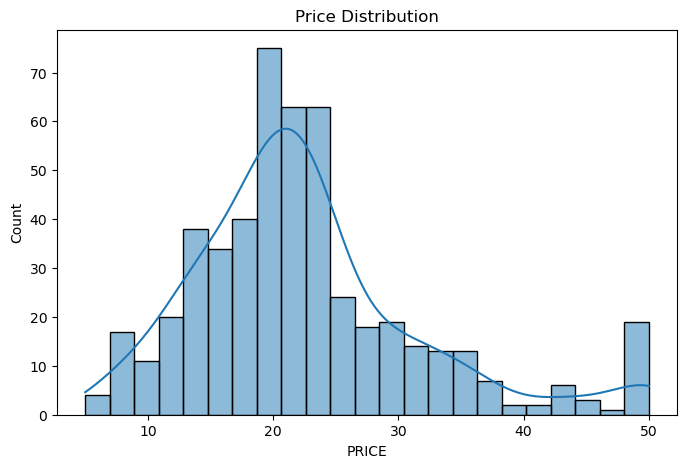

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(df["PRICE"], kde=True)
plt.title("Price Distribution")
plt.show()


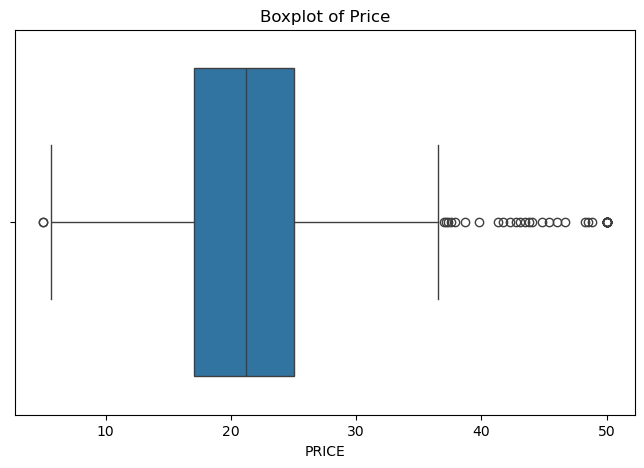

In [44]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["PRICE"])
plt.title("Boxplot of Price")
plt.show()

In [45]:
correlation = df.corr()
print("\nCorrelation with PRICE:")
print(correlation["PRICE"])


Correlation with PRICE:
CRIM      -0.388305
ZN         0.360445
INDUS     -0.483725
CHAS       0.175260
NOX       -0.427321
RM         0.695360
AGE       -0.376955
DIS        0.249929
RAD       -0.381626
TAX       -0.468536
PTRATIO   -0.507787
B          0.333461
LSTAT     -0.737663
PRICE      1.000000
Name: PRICE, dtype: float64


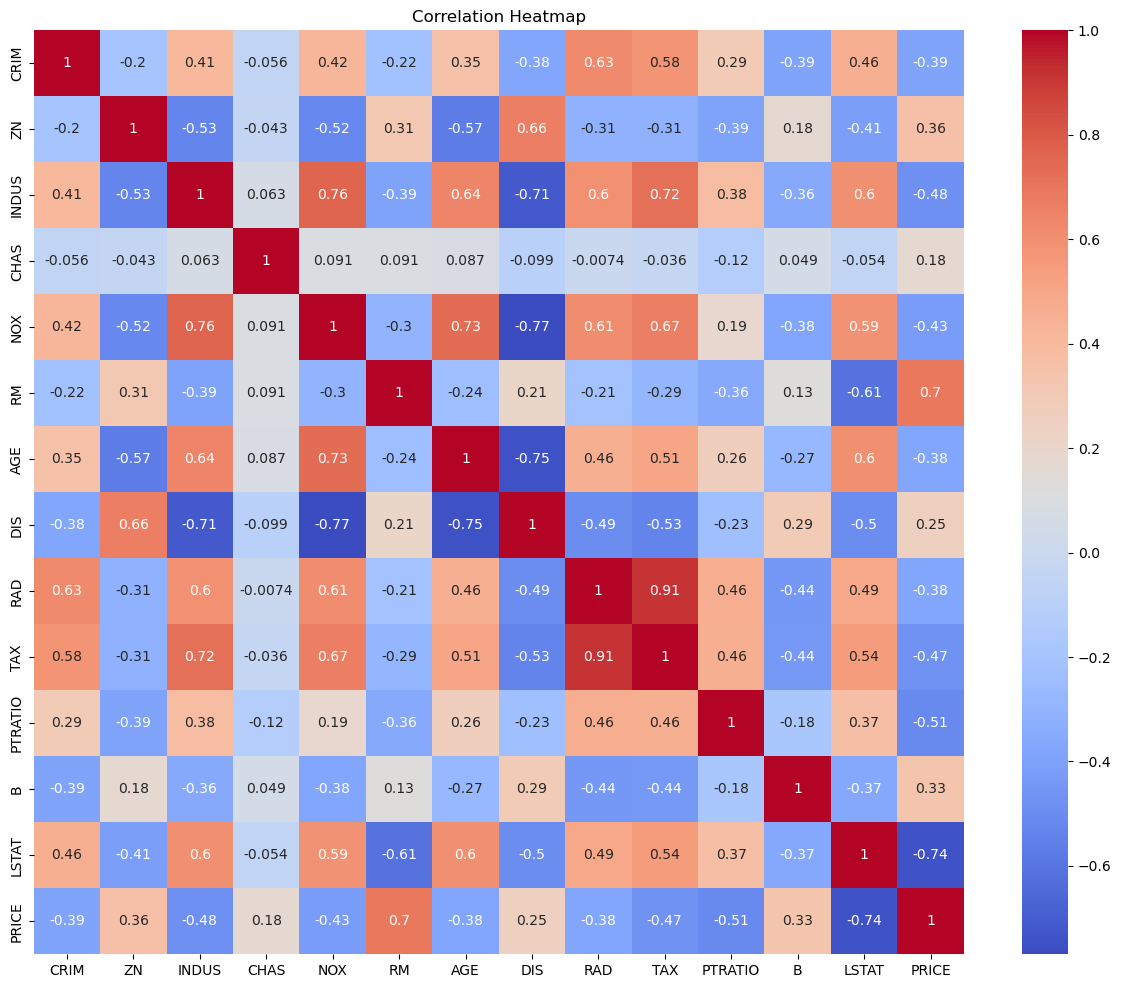

In [46]:
plt.figure(figsize=(15,12))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [47]:
features = ['LSTAT', 'RM', 'PTRATIO']
plt.figure(figsize=(18,5))

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

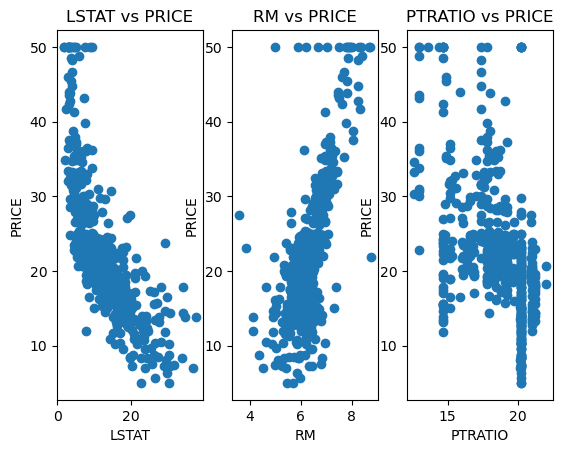

In [48]:
for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    plt.scatter(df[col], df["PRICE"])
    plt.xlabel(col)
    plt.ylabel("PRICE")
    plt.title(f"{col} vs PRICE")

In [49]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [50]:
X = df.iloc[:, :-1]
y = df["PRICE"]

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
y_pred_lr = lr_model.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("\n===== Linear Regression Results =====")
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)
print("MAE :", mae_lr)
print("R2 Score:", r2_lr)



===== Linear Regression Results =====
MSE : 24.29111947497351
RMSE: 4.928602182665336
MAE : 3.1890919658878483
R2 Score: 0.6687594935356321


In [53]:
model = Sequential()

model.add(Input(shape=(13,)))

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 128)                 │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,673 (49.50 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_split=0.05,
    verbose=1
)


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 579.7758 - mae: 22.1532 - val_loss: 468.2990 - val_mae: 20.0866
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 490.6684 - mae: 19.8314 - val_loss: 337.0902 - val_mae: 16.4565
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 306.8344 - mae: 14.9622 - val_loss: 132.0584 - val_mae: 8.9112
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 116.0543 - mae: 8.6826 - val_loss: 62.0065 - val_mae: 5.1097
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 63.1205 - mae: 6.0675 - val_loss: 68.0541 - val_mae: 5.0758
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 38.3347 - mae: 4.5798 - val_loss: 62.5103 - val_mae: 5.1629
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 29.2052 - mae: 4.0090 - val_loss: 55.4564 - val_mae: 5.1144
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 24.8141 - mae: 3.6478 - val_loss: 57.5908 - val_mae: 4.8935
Epoch 9/100
12/12 ━━━━━━━━━━

In [55]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    y=history.history['loss'],
    mode='lines',
    name='Training Loss'
))

In [56]:
fig.add_trace(go.Scatter(
    y=history.history['val_loss'],
    mode='lines',
    name='Validation Loss'
))

In [57]:
fig.update_layout(
    title='Model Loss',
    xaxis_title='Epoch',
    yaxis_title='Loss',
    height=500,
    width=700
)
fig.show()

In [58]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    y=history.history['mae'],
    mode='lines',
    name='Training MAE'
))

In [59]:
fig.add_trace(go.Scatter(
    y=history.history['val_mae'],
    mode='lines',
    name='Validation MAE'
))

In [60]:
fig.update_layout(
    title='Model MAE',
    xaxis_title='Epoch',
    yaxis_title='MAE',
    height=500,
    width=700
)
fig.show()

In [61]:
y_pred_nn = model.predict(X_test)

mse_nn = mean_squared_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mse_nn)
mae_nn = mean_absolute_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print("\n===== Neural Network Results =====")
print("MSE :", mse_nn)
print("RMSE:", rmse_nn)
print("MAE :", mae_nn)
print("R2 Score:", r2_nn)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

===== Neural Network Results =====
MSE : 9.96061460070749
RMSE: 3.1560441379529993
MAE : 1.9872922116634892
R2 Score: 0.8641742704187031


In [62]:
new_data = np.array([[
    0.1, 10.0, 5.0, 0, 0.4,
    6.0, 50, 6.0, 1, 400,
    20, 300, 10
]])


In [63]:
prediction = model.predict(new_data_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


In [64]:
print("\nPredicted House Price:")
print(prediction)


Predicted House Price:
[[15.05476]]
